### **[A]: Choice of a population, with supporting expenditure data**

In [2]:
!pip install -r requirements.txt

In [9]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import eep153_tools

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [10]:
#Prices
ugd3_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2011-12).csv')
ugd3_p0 = ugd3_p0[ugd3_p0["u"] == "Kg"]
ugd3_p = pd.pivot_table(ugd3_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd3_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2011-12).csv')
ugd3_x0['i'] = ugd3_x0['i'].astype(str)
ugd3_x = pd.pivot_table(ugd3_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd3_x_long = ugd3_x.stack().reset_index(name="Expenditure")
ugd3_p_long = ugd3_p0
ugd3_c = ugd3_x_long.merge(ugd3_p_long, on=["j", "t", "m"], how="left")
ugd3_c["Consumption"] = ugd3_c["Expenditure"] / ugd3_c["price"]
ugd3_c = ugd3_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd3_z = ugd_z0[ugd_z0['t'] == '2011-12']
ugd3_z = ugd3_z.set_index(['i','t','m'])
ugd3_z.columns.name = 'k'
ugd3_z.fillna(0, inplace=True)

### **[B]: Nutritional content of different foods**

In [11]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

In [12]:
import cfe
from cfe import Regression

ugd3_result = cfe.Regression(y=np.log(ugd3_x.stack()),d=ugd3_z)

In [13]:
ugd3_result.predicted_expenditures()

i           t        m        j                     
1013000201  2011-12  Central  Avocado                   1338.440146
                              Beans (dry)               4552.524246
                              Beans (fresh)             5262.019163
                              Beef                      7728.913985
                              Bread                     2923.720191
                                                           ...     
4193003508  2011-12  Western  Sugar                     3035.336838
                              Sweet Bananas             4555.682158
                              Sweet Potatoes (fresh)    5461.790743
                              Tea                        361.651847
                              Tomatoes                  1952.941198
Length: 93499, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

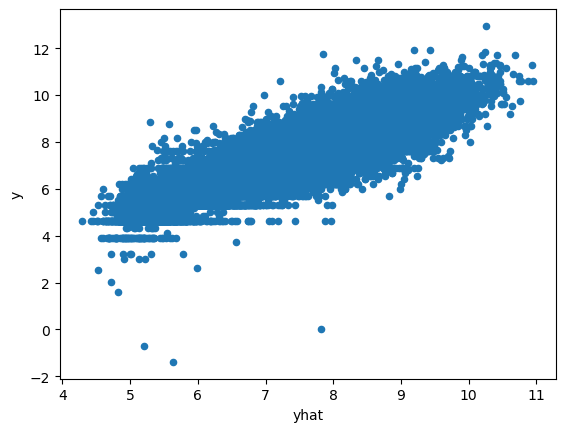

In [42]:
#Expenditures x may have duplicate columns
x1 = ugd3_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd3_acc = pd.DataFrame({'y':y,'yhat':ugd3_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd3_acc.plot.scatter(x='yhat',y='y')

In [45]:
ugd3_result.R2(summary=True)

0.7696623232417942

In [46]:
#Save result
ugd3_result.to_pickle('./Uganda11-12.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda11-12.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

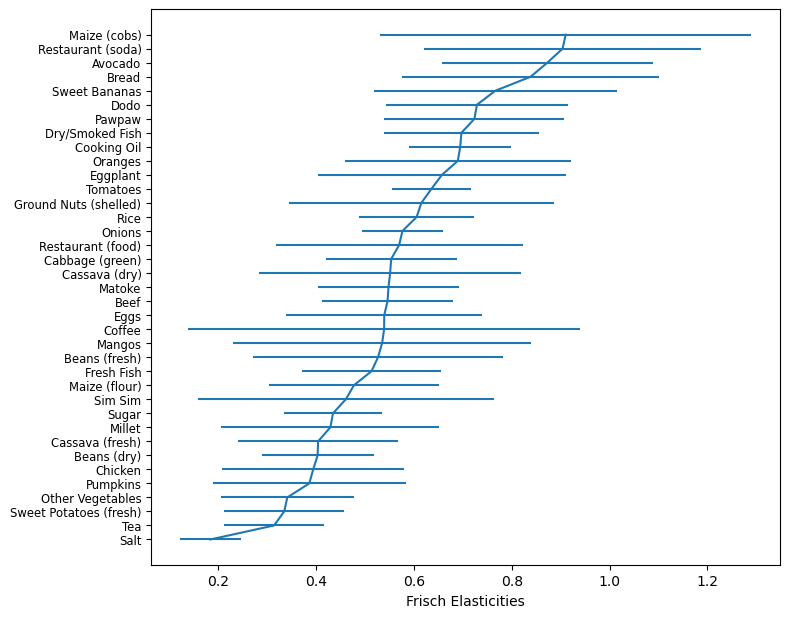

In [48]:
ax1 = ugd3_result.graph_beta()

In [49]:
ugd3_result.get_beta().sort_values(ascending=False)

j
Maize (cobs)              0.910309
Restaurant (soda)         0.903950
Avocado                   0.872730
Bread                     0.838655
Sweet Bananas             0.766446
Dodo                      0.728898
Pawpaw                    0.723864
Dry/Smoked Fish           0.697156
Cooking Oil               0.694860
Oranges                   0.689823
Eggplant                  0.657349
Tomatoes                  0.635941
Ground Nuts (shelled)     0.615351
Rice                      0.605793
Onions                    0.576771
Restaurant (food)         0.569981
Cabbage (green)           0.553698
Cassava (dry)             0.551628
Matoke                    0.548219
Beef                      0.546362
Eggs                      0.539528
Coffee                    0.539316
Mangos                    0.535175
Beans (fresh)             0.526873
Fresh Fish                0.513552
Maize (flour)             0.477667
Sim Sim                   0.461135
Sugar                     0.434850
Millet            

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [50]:
ugd3_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Avocado,0.034195,-0.100845,0.032602,-0.055209,0.021540,0.032038,0.061649,0.003349,0.001255,0.139701,-0.047931,0.090471,0.194188,0.267423,0.325492,7.166030
Beans (dry),-0.082697,0.042486,-0.007873,0.057448,0.031235,0.105527,0.094744,-0.071551,-0.036402,0.011747,0.045244,0.052613,0.069718,0.089046,0.401105,8.078222
Beans (fresh),-0.129357,-0.002209,0.023115,0.069029,0.019630,-0.069036,-0.053714,-0.139967,0.016011,0.074501,-0.042732,-0.036788,-0.055942,0.142422,0.522663,8.033387
Beef,-0.003825,0.002035,0.027405,0.018729,0.072102,0.041962,-0.043154,-0.021724,-0.050179,0.001533,0.047561,0.076050,0.101599,0.064643,0.298289,8.892449
Bread,-0.007773,-0.012290,0.060607,0.094355,0.156658,0.177350,-0.023057,0.078526,-0.093926,0.022508,0.026786,0.130757,0.323020,0.157394,0.075646,7.914692
Cabbage (green),0.011402,-0.058245,-0.027058,0.034573,0.050103,0.107100,0.029424,-0.084102,-0.078386,-0.005477,0.020217,-0.018351,0.056784,0.034319,0.314804,6.971064
Cassava (dry),0.043478,-0.050075,0.138791,-0.111954,-0.172148,-0.202892,0.028047,-0.086270,-0.013033,0.052510,0.000695,0.038224,-0.073689,0.077245,0.696637,8.620994
Cassava (fresh),-0.015060,0.013446,0.093624,0.105521,-0.044155,-0.046237,0.013043,-0.036020,0.044257,0.093307,0.128561,0.057018,0.017585,0.000442,0.355197,8.063809
Chicken,0.051149,-0.009683,-0.022746,0.031714,0.156449,0.170516,0.039451,0.017224,-0.032384,-0.012992,0.127406,0.094614,0.182220,0.170725,-0.167091,9.324031


**Welfare:** $w_i$ parameters, which are a welfare measure for the household.

<Axes: ylabel='Density'>

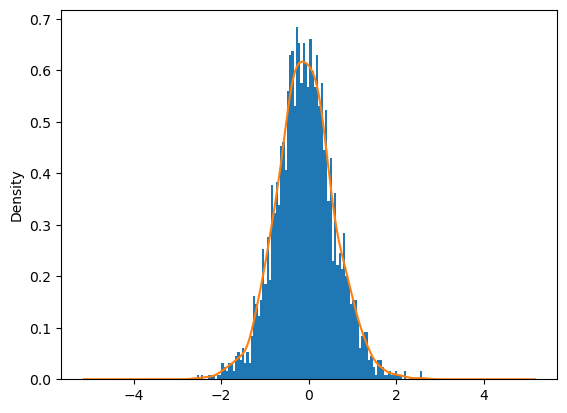

In [51]:
ax2 = ugd3_result.get_w().plot.hist(bins=100,density=True)
ugd3_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [15]:
xhat = ugd3_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [16]:
#Prices per kilogram:
pbar = ugd3_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd3_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Beef Demanded')

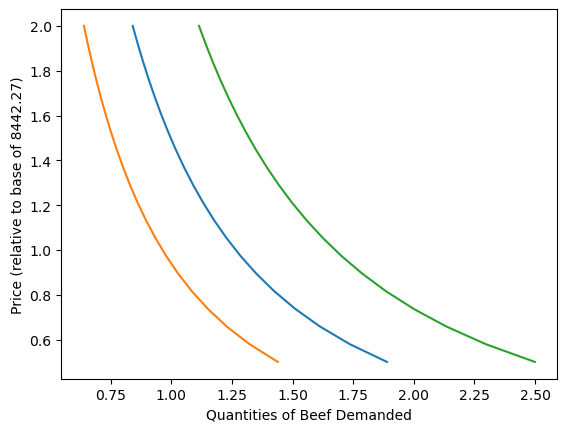

In [17]:
use = 'Beef'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd3_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd3_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd3_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

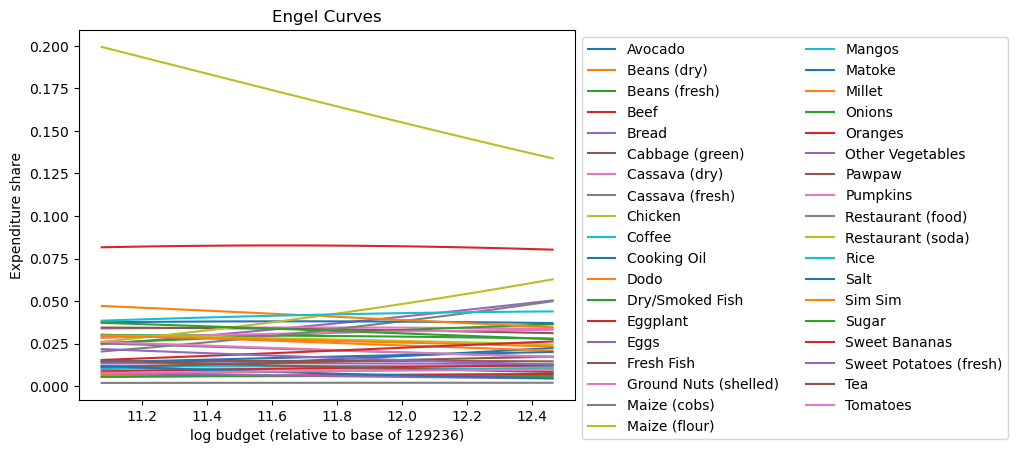

In [18]:
fig,ax = plt.subplots()

ax.plot(np.log(scale*xref),[ugd3_result.expenditures(s*xref,pbar)/(s*xref) for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')
ax.legend(ugd3_result.expenditures(xref,pbar).index.tolist(), loc="upper left", bbox_to_anchor=(1, 1), ncol=2)

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

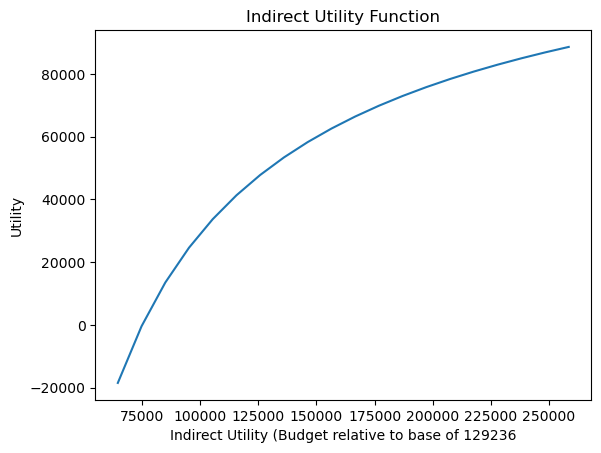

In [19]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd3_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [20]:
#Get result saved above
ugd3_result = cfe.read_pickle('Uganda11-12.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd3_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [21]:
#Coluns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          136538.293432
Protein           6102.342183
Fiber             2289.976849
Folate           33803.374170
Calcium          26515.446924
Carbohydrate     21579.494314
Iron               913.537736
Niacin            1330.083454
Riboflavin          79.664490
Thiamin            105.723501
Vitamin A        26160.164490
Vitamin B-12       322.062401
Vitamin B-6        208.020276
Vitamin C         9777.790019
Zinc               523.783559
Magnesium            3.982019
Phosphorus           2.986514
Potassium           55.005525
Vitamin E            0.000000
Vitamin K            0.000000
dtype: float64

In [22]:
#Obtain recommended daily intake
ugd3_z = ugd3_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd3_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
1013000201,2011-12,Central,1.104646,2.356070,1.288442,1.624808,0.344430,2.557567,1.220633,1.458978,1.215935,1.583768,0.608252,2.659591,2.849497,2.138021,0.926355,0.000109,0.000029,0.000112,0.0,0.0
1013000202,2011-12,Central,2.067389,5.217600,2.284377,2.857301,0.600789,3.850378,1.945089,2.979140,2.399790,2.890799,1.210928,5.549339,5.308589,4.420583,1.958285,0.000313,0.000061,0.000247,0.0,0.0
1013000204,2011-12,Central,1.806158,4.619662,1.973109,2.292670,0.442099,2.740655,2.001564,2.507611,1.964022,2.365168,0.965238,4.591232,4.329463,4.038772,1.724618,0.000219,0.000040,0.000158,0.0,0.0
1013000206,2011-12,Central,1.721858,3.110354,1.770556,1.926425,0.576127,3.812287,2.699989,2.155572,1.660023,2.049544,0.715065,4.065508,3.634429,2.390730,1.264944,0.000180,0.000075,0.000227,0.0,0.0
1013000210,2011-12,Central,3.400369,5.710563,3.462936,3.105915,0.871553,5.864530,4.316084,3.739782,3.110898,3.446036,1.666071,6.687466,5.148039,4.083934,2.566989,0.000420,0.000144,0.000440,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4193003210,2011-12,Western,1.296697,2.397797,1.872252,1.941767,0.425109,2.919487,1.245197,1.619475,1.397439,2.024634,0.691112,2.018055,3.222280,2.604984,1.142226,0.000171,0.000043,0.000158,0.0,0.0
4193003502,2011-12,Western,3.004121,6.428603,4.348106,5.540577,1.092623,7.002280,3.862533,4.392560,3.386524,5.053876,1.482222,6.130736,8.649211,6.240545,2.809494,0.000198,0.000060,0.000182,0.0,0.0
4193003504,2011-12,Western,1.297103,2.577356,1.829506,2.173483,0.530474,3.199470,1.488458,1.762942,1.418306,2.126558,0.732768,2.446323,3.557412,2.703362,1.209524,0.000087,0.000027,0.000095,0.0,0.0


<Axes: >

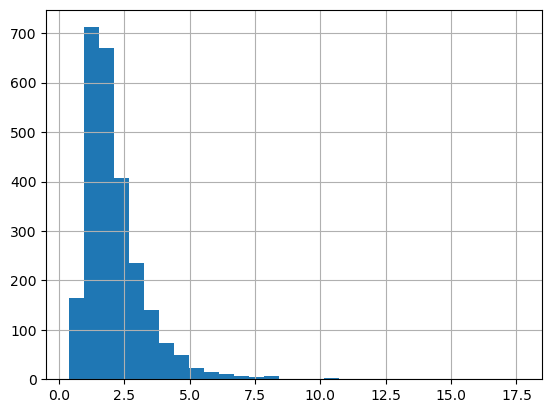

In [23]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)